In [51]:
import tensorflow as tf
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
x_train = x_train / 255.0
x_test = x_test / 255.0

In [52]:
x_train.shape  #rgb images 3 channels

(50000, 32, 32, 3)

In [53]:
y_train.shape

(50000, 1)

In [54]:
y_train[:10]

array([[6],
       [9],
       [9],
       [4],
       [1],
       [1],
       [2],
       [7],
       [8],
       [3]], dtype=uint8)

In [55]:
from tensorflow.keras import layers, models

In [56]:
#we will one hot encode the y_train and y_test
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

In [57]:
y_train,y_train.shape

(array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 1.],
        [0., 0., 0., ..., 0., 0., 1.],
        ...,
        [0., 0., 0., ..., 0., 0., 1.],
        [0., 1., 0., ..., 0., 0., 0.],
        [0., 1., 0., ..., 0., 0., 0.]]),
 (50000, 10))

In [64]:
#we define the cnn architecture
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),  # no of filters of size 3x3 is 32
    layers.MaxPooling2D((2, 2)), # matrix of size 2x2

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),


    layers.Flatten(),

    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax') #output layer
])


In [65]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',  #the loss is suited for more than 2 clasess
              metrics=['accuracy'])


In [66]:
history = model.fit(x_train, y_train, epochs=40,
                    validation_data=(x_test, y_test),
                    batch_size=128)  #traning the model


Epoch 1/40
391/391 ━━━━━━━━━━━━━━━━━━━━ 75s 188ms/step - accuracy: 0.2843 - loss: 1.9502 - val_accuracy: 0.5074 - val_loss: 1.3765
Epoch 2/40
391/391 ━━━━━━━━━━━━━━━━━━━━ 82s 189ms/step - accuracy: 0.4744 - loss: 1.4544 - val_accuracy: 0.5714 - val_loss: 1.2395
Epoch 3/40
391/391 ━━━━━━━━━━━━━━━━━━━━ 79s 182ms/step - accuracy: 0.5281 - loss: 1.3123 - val_accuracy: 0.5856 - val_loss: 1.1837
Epoch 4/40
391/391 ━━━━━━━━━━━━━━━━━━━━ 83s 185ms/step - accuracy: 0.5642 - loss: 1.2284 - val_accuracy: 0.6311 - val_loss: 1.0718
Epoch 5/40
391/391 ━━━━━━━━━━━━━━━━━━━━ 83s 187ms/step - accuracy: 0.5876 - loss: 1.1530 - val_accuracy: 0.6493 - val_loss: 1.0289
Epoch 6/40
391/391 ━━━━━━━━━━━━━━━━━━━━ 81s 185ms/step - accuracy: 0.6104 - loss: 1.1042 - val_accuracy: 0.6580 - val_loss: 0.9938
Epoch 7/40
391/391 ━━━━━━━━━━━━━━━━━━━━ 82s 184ms/step - accuracy: 0.6304 - loss: 1.0470 - val_accuracy: 0.6639 - val_loss: 0.9694
Epoch 8/40
391/391 ━━━━━━━━━━━━━━━━━━━━ 71s 181ms/step - accuracy: 0.6400 - loss: 1

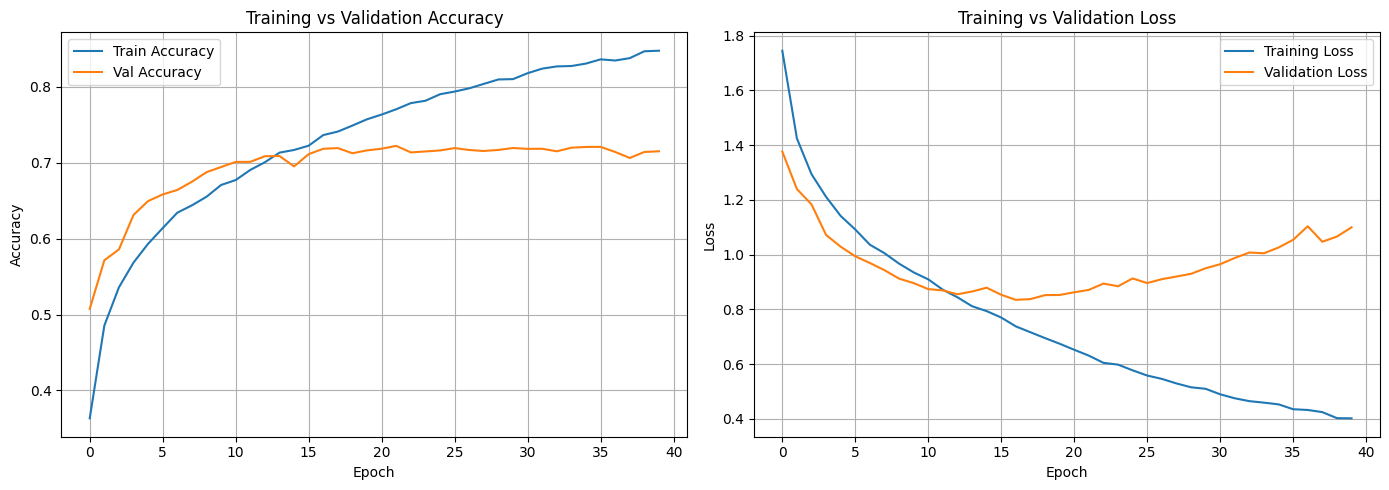

In [67]:
import matplotlib.pyplot as plt
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].plot(history.history['accuracy'], label='Train Accuracy')
axs[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axs[0].set_title("Training vs Validation Accuracy")
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Accuracy')
axs[0].legend()
axs[0].grid(True)

axs[1].plot(history.history['loss'], label='Training Loss')
axs[1].plot(history.history['val_loss'], label='Validation Loss')
axs[1].set_title("Training vs Validation Loss")
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Loss')
axs[1].legend()
axs[1].grid(True)

# combined plot
plt.tight_layout()
plt.show()


In [ ]:
#we should have stopped  on epoch 20
test_loss, test_acc = model.evaluate(x_test, y_test)
test_loss ,test_acc


313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.7173 - loss: 1.0813


(1.099640130996704, 0.7148000001907349)